# Cách Dự báo Time-Series sử dụng ARIMA



## Giới thiệu



Trong các bài viết trước, chúng ta đã đề cập đến autoregression (AR) và moving-average (MA) models. Tuy nhiên, bạn có biết điều gì tốt hơn hai mô hình này không? Một mô hình duy nhất kết hợp cả hai!

Autoregressive Integrated Moving Average hay còn được biết đến là ARIMA, có lẽ là mô hình dự báo time series được sử dụng nhiều nhất và là sự kết hợp của các mô hình riêng lẻ đã nói ở trên.

Trong bài viết này, tôi muốn đi sâu vào lý thuyết và framework (khung) đằng sau mô hình ARIMA. Sau đó, chúng ta sẽ xem qua một hướng dẫn Python đơn giản trong việc thực hiện forecast (dự báo) với ARIMA bằng cách sử dụng package statsmodels!



## ARIMA là gì?




### Tổng quan


Như đã nói ở trên, ARIMA là viết tắt của AutoRegressive Integrated Moving Average về cơ bản chỉ là sự kết hợp của ba (thực tế là hai) thành phần:



**AutoRegressive (AR):**


Đây chỉ là autoregression, nơi chúng ta dự báo các giá trị tương lai bằng cách sử dụng một tổ hợp tuyến tính của các giá trị quan sát trước đó:


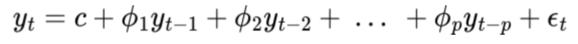

Ở đây y là time series chúng ta đang dự báo tại nhiều bước thời gian, ϕ là các coefficients (hệ số) của các lags (độ trễ), ε là error term (sai số) (thường được phân phối chuẩn) và p là số lượng các thành phần lagged, còn được gọi là order (bậc).


**Integrated (I):**


Phần giữa của mô hình ARIMA được đặt tên là integrated. Đây là số lượng (order d) của differencing (lấy sự khác biệt) cần thiết để làm cho time series stationary (dừng).

Stationarity (Tính dừng) là nơi time series có mean (trung bình) và variance (phương sai) không đổi, có nghĩa là các thuộc tính thống kê của chuỗi không thay đổi theo thời gian. Differencing loại bỏ trend (xu hướng) của time series và có xu hướng làm cho mean không đổi. Bạn có thể áp dụng differencing nhiều lần, nhưng thường chuỗi đã đủ stationary sau một bước differencing duy nhất.

Điều quan trọng cần lưu ý là phần integrated này chỉ làm cho mean không đổi. Chúng ta cần áp dụng một biến đổi khác như logarithmic và Box-Cox transform để tạo ra variance không đổi (sẽ nói thêm về điều này sau).


**Moving Average (MA):**


Thành phần cuối cùng là moving average nơi bạn dự báo bằng cách sử dụng các forecast errors (sai số dự báo) trong quá khứ thay vì các giá trị quan sát thực tế:


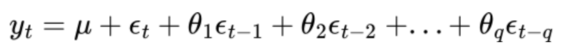

Ở đây y là time series chúng ta đang dự báo tại nhiều bước thời gian, μ là mean (trung bình), θ là các coefficients (hệ số) của các lagged forecast errors, ε là các forecast error terms và q là số lượng các thành phần lagged error.



**Dạng cuối cùng:**


Kết hợp tất cả các thành phần này lại với nhau, chúng ta có thể viết mô hình đầy đủ như sau:



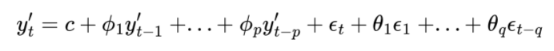

Trong đó y' đề cập đến phiên bản đã differenced của time series.

Đây là phương trình ARIMA đầy đủ và chỉ là tổng tuyến tính của ba thành phần. Mô hình thường được viết theo cách viết tắt là ARIMA(p, d, q) trong đó p, d và q đề cập đến order (bậc) của các thành phần autoregressors, differencing và moving-averages tương ứng.


### Yêu cầu


Như chúng ta đã đề cập trước đó, thành phần differencing ở đó để giúp làm cho time series stationary (dừng). Điều này là do mô hình ARIMA yêu cầu dữ liệu phải stationary để nó có thể mô hình hóa đầy đủ. Mean (Trung bình) được ổn định thông qua differencing và variance (phương sai) có thể được ổn định thông qua biến đổi Box-Cox như chúng ta đã đề cập ở trên.



### Lựa chọn Order (Bậc)


Một trong các bước preprocessing (tiền xử lý) là xác định các orders (bậc) tối ưu (p, d, q) của mô hình ARIMA của chúng ta. Đơn giản nhất là order của differencing d vì điều này có thể được xác minh bằng cách thực hiện kiểm định thống kê cho stationarity. Phổ biến nhất là Augmented Dickey-Fuller (ADF), trong đó giả thuyết null là time series không stationary.

Các orders autoregressive và moving-average (p,q) có thể được suy ra bằng cách phân tích partial autocorrelation function (PACF) và autocorrelation function tương ứng. Ý chính của phương pháp này là vẽ correlogram (biểu đồ tương quan) của các lags/forecast errors khác nhau của time series để xác định lags nào có ý nghĩa thống kê. Nếu điều này có vẻ tùy tiện vào lúc này, đừng lo lắng, trong hướng dẫn Python sau này chúng ta sẽ xem qua quy trình này.

Tuy nhiên, một kỹ thuật kỹ lưỡng hơn là chỉ đơn giản lặp qua tất cả các tổ hợp có thể có của các orders và chọn mô hình có điểm số tốt nhất đối với một metric (chỉ số) như Akaike's Information Criterion (AIC) hoặc Bayesian Information Criterion (BIC). Điều này tương tự như hyperparameter tuning thông thường và chắc chắn là phương pháp mạnh mẽ hơn, nhưng tất nhiên tốn kém hơn về mặt tính toán.



### Ước lượng


Sau khi chọn các orders của chúng ta, sau đó chúng ta cần tìm các coefficients (hệ số) tối ưu tương ứng của chúng. Đây là nơi nhu cầu về stationarity xuất hiện. Như đã tuyên bố ở trên, một time series stationary có các thuộc tính thống kê không đổi như mean (trung bình) và variance (phương sai). Do đó, tất cả các điểm dữ liệu là một phần của cùng một phân phối xác suất, điều này làm cho việc fitting (khớp) mô hình của chúng ta dễ dàng hơn. Hơn nữa, các forecasts (dự báo) được coi là các biến ngẫu nhiên và bây giờ sẽ thuộc về cùng một phân phối xác suất với time series stationary mới được tạo ra. Nhìn chung, nó giúp làm cho dữ liệu trong tương lai giống với quá khứ.

Vì dữ liệu stationary thuộc về một phân phối nào đó (thường là phân phối chuẩn), chúng ta có thể ước lượng các coefficients bằng Maximum Likelihood Estimation (MLE - Ước lượng hợp lý cực đại). MLE suy ra các giá trị tối ưu của các coefficients tạo ra xác suất cao nhất để có được dữ liệu đó. MLE cho dữ liệu phân phối chuẩn, cho kết quả tương tự như thực hiện ordinary least squares. Do đó, least squares cũng thường được sử dụng chính vì lý do này.


## Hướng dẫn Python




### Dữ liệu


In [1]:
# Import các package
import plotly.express as px
import pandas as pd

# Đọc dữ liệu
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])


def plot_passenger_volumes(df: pd.DataFrame,
                           y: str) -> None:
    """Hàm chung để vẽ dữ liệu hành khách."""

    fig = px.line(df, x='Month', y=y, labels={'Month': 'Date'})
    fig.update_layout(template="simple_white", font=dict(size=18), title_text='Hành khách Hàng không',
                      width=650, title_x=0.5, height=400)

    return fig.show()


# Vẽ biểu đồ dữ liệu hành khách hàng không
plot_passenger_volumes(df=data, y='#Passengers')


Dữ liệu không stationary (dừng) vì có một trend (xu hướng) dương mạnh và các biến động seasonality (tính mùa vụ) hàng năm đang tăng theo thời gian, do đó variance (phương sai) đang tăng. Đối với nhiệm vụ modelling (mô hình hóa) này, chúng ta sẽ sử dụng package statsmodel, thứ mà tiện lợi thực hiện differencing cho chúng ta và tạo ra mean (trung bình) không đổi. Tuy nhiên, chúng ta vẫn cần áp dụng biến đổi Box-Cox để có được variance ổn định:


In [2]:
# Import các package 
from scipy.stats import boxcox

# Làm cho variance của target stationary
data['Passengers_Boxcox'], lam = boxcox(data['#Passengers'])

# Vẽ biểu đồ dữ liệu hành khách đã qua box-cox
plot_passenger_volumes(df=data, y='Passengers_Boxcox')


Dữ liệu bây giờ có vẻ stationary (dừng). Chúng ta có thể làm cho nó stationary hơn nữa bằng cách thực hiện differencing bậc hai hoặc seasonal differencing, tuy nhiên tôi nghĩ nó đã đạt yêu cầu ở đây.


### Mô hình hóa


Trong các phần trước, tôi đã đề cập cách bạn có thể tìm các orders autoregressive và moving-average bằng cách vẽ các hàm autocorrelation và partial autocorrelation. Hãy cho xem một ví dụ về cách bạn có thể làm điều đó ở đây:


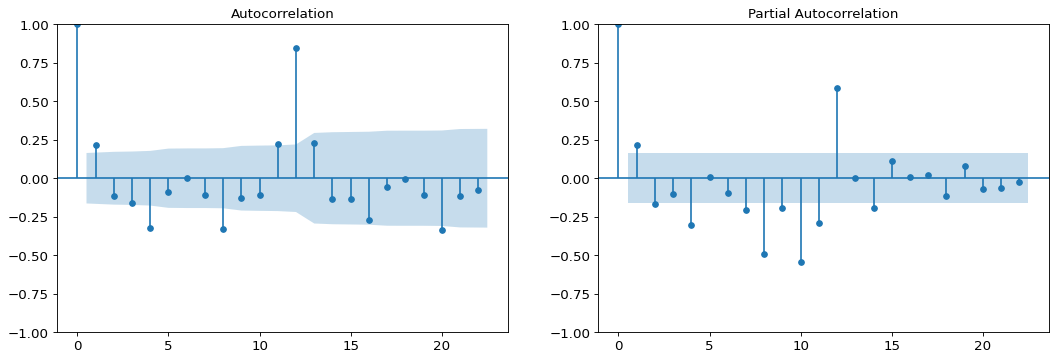

In [3]:
# Import các package
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

# Difference dữ liệu
data["Passenger_diff"] = data["Passengers_Boxcox"].diff()
data.dropna(inplace=True)

# Vẽ acf và pacf
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,5), dpi=80)
plot_acf(data['Passenger_diff'], ax=ax1)
plot_pacf(data['Passenger_diff'], method='ywm', ax=ax2)
ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)
plt.show()


Vùng màu xanh biểu thị nơi các điểm không còn có ý nghĩa thống kê và từ biểu đồ, chúng ta thấy lag cuối cùng có ý nghĩa thống kê cho cả hai biểu đồ là ~lag thứ 12. Do đó, chúng ta sẽ lấy order của p và q là 12.

Bây giờ, hãy fit mô hình bằng cách sử dụng hàm ARIMA từ statsmodels và tạo ra các forecasts (dự báo):


In [4]:
# Import các package
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox

# Chia train và test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]

# Xây dựng mô hình ARIMA và đảo ngược boxcox
model = ARIMA(train['Passengers_Boxcox'], order=(12, 1, 12)).fit()
boxcox_forecasts = model.forecast(len(test))
forecasts = inv_boxcox(boxcox_forecasts, lam)


c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\U

### Kết quả


Các forecasts (dự báo) được tạo ra từ mô hình đã fit này là cho time series đã được differenced và biến đổi Box-Cox mà chúng ta đã tạo ra trước đó. Do đó, chúng ta phải un-difference (đảo ngược differencing) và áp dụng biến đổi Box-Cox nghịch đảo cho các predictions (dự đoán) để có được khối lượng hành khách hàng không được dự báo thực tế:


In [5]:
# Import các package
import plotly.graph_objects as go

def plot_forecasts(forecasts: list[float], title: str) -> None:
    """Hàm để vẽ các forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['Month'], y=train['#Passengers'], name='Train'))
    fig.add_trace(go.Scatter(x=test['Month'], y=test['#Passengers'], name='Test'))
    fig.add_trace(go.Scatter(x=test['Month'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Ngày',
                      yaxis_title='Khối lượng Hành khách')

    return fig.show()


# Vẽ biểu đồ các forecasts
plot_forecasts(forecasts, 'ARIMA')
